<a href="https://colab.research.google.com/github/SkyWarLimit/PCVK26_17_MIhsanR/blob/main/Week05_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PERSIAPAN DATA**

In [4]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Muhammad Ihsan Rahmatullah'
NIM = '244107020218'
N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

BASE = f'/content/drive/MyDrive/PCVK/Image/{NIM}'
CONTOH = '/content/drive/MyDrive/PCVK'

import matplotlib.pyplot as plt

def set_title_wajib():
    plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']), fontsize=9)

NAMA : Muhammad Ihsan Rahmatullah
NIM : 244107020218 | N = 218
bins   : 32
clip   : 2.5
tile   : 4
L      : 8
WAKTU : 2026-09-27 18:24:00 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 1d13653088a86f3c


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

**PRAKTIKUM E-1**

<BarContainer object of 256 artists>

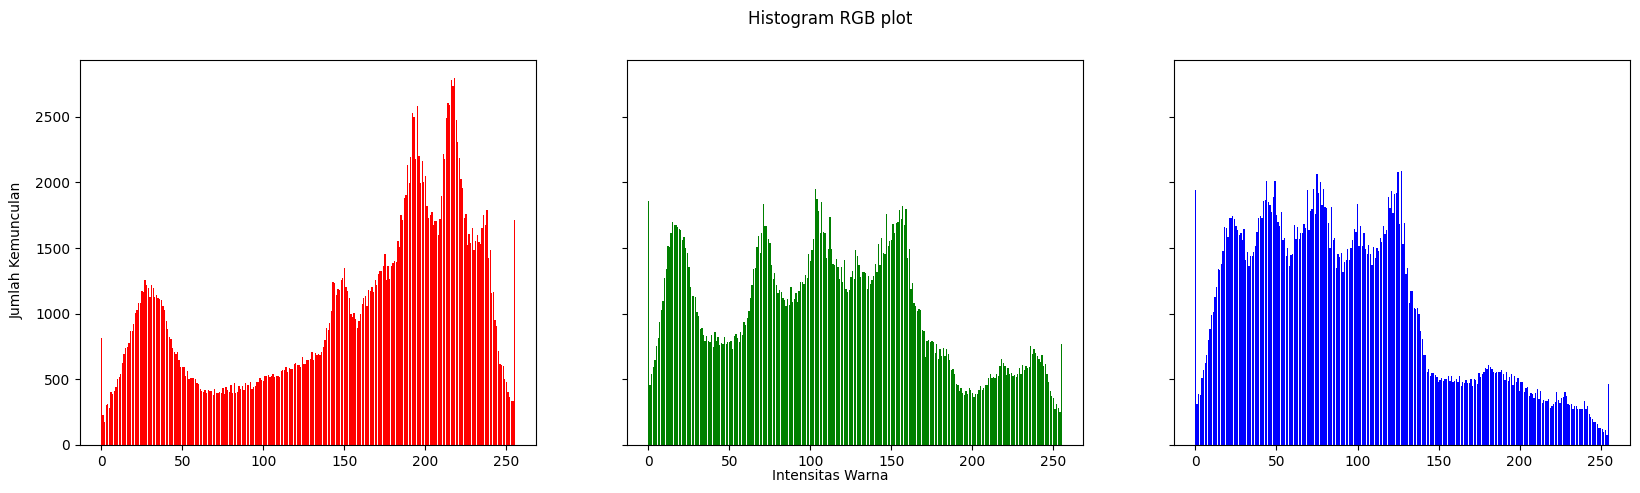

In [7]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**PERTANYAAN**

**NO 1**


--- Pembuktian pada: /content/drive/MyDrive/PCVK/Image/244107020218/KTP1b.jpg ---
Selisih maksimal Manual vs NumPy : 0
Selisih maksimal Manual vs OpenCV: 0.0


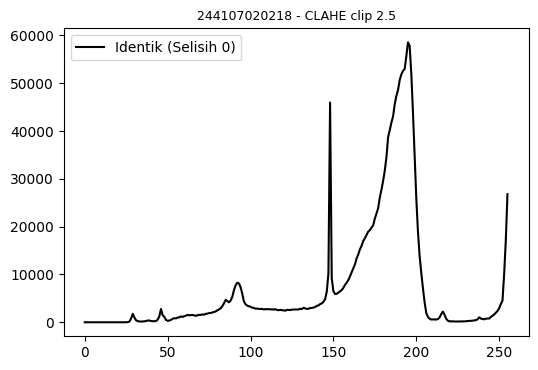

In [8]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

uji_coba = [f'{BASE}/KTP1b.jpg']

for path in uji_coba:
    img_gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img_gray is not None:
        print(f"\n--- Pembuktian pada: {path} ---")

        hist_manual = histogram_manual(img_gray)
        hist_np, _ = np.histogram(img_gray.ravel(), bins=256, range=[0, 256])
        hist_cv = cv.calcHist([img_gray], [0], None, [256], [0, 256]).ravel()

        diff_np = np.max(np.abs(hist_manual - hist_np))
        diff_cv = np.max(np.abs(hist_manual - hist_cv))

        print("Selisih maksimal Manual vs NumPy :", diff_np)
        print("Selisih maksimal Manual vs OpenCV:", diff_cv)

        plt.figure(figsize=(6,4))
        plt.plot(hist_manual, color='black', label='Identik (Selisih 0)')
        set_title_wajib()
        plt.legend()
        plt.show()

**NO 2**

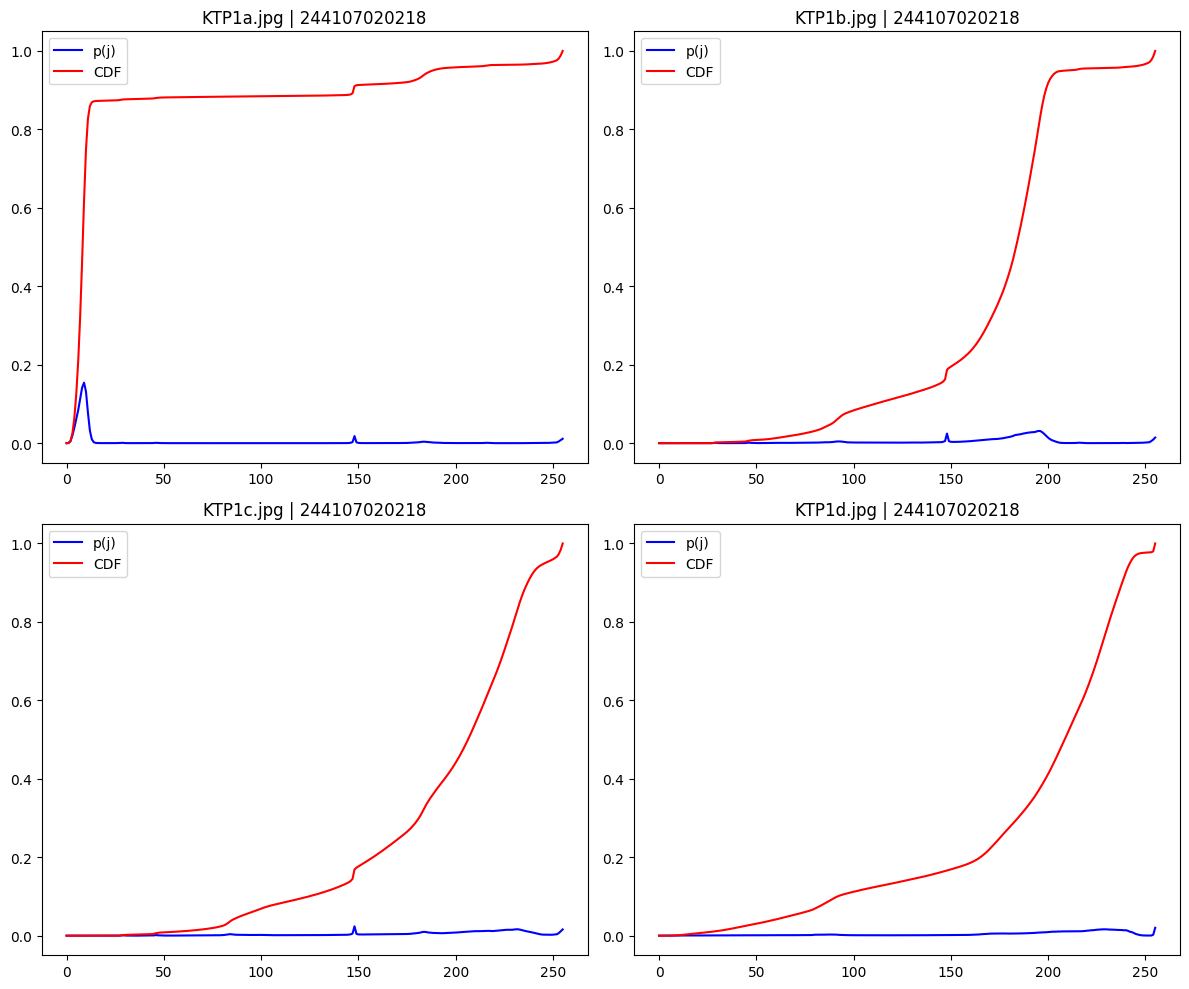

In [9]:
citra_list = ['KTP1a.jpg', 'KTP1b.jpg', 'KTP1c.jpg', 'KTP1d.jpg']
plt.figure(figsize=(12, 10))

for i, filename in enumerate(citra_list):
    path = f'{BASE}/{filename}'
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is not None:
        h = histogram_manual(img)
        p = h / img.size             # Normalisasi
        cdf = np.cumsum(p)           # Distribusi kumulatif

        plt.subplot(2, 2, i+1)
        plt.plot(p, label='p(j)', color='blue')
        plt.plot(cdf, label='CDF', color='red')
        plt.title(f"{filename} | {NIM}")
        plt.legend()
    else:
        print(f"File {filename} tidak ditemukan!")
plt.tight_layout()
plt.show()

**NO 3**

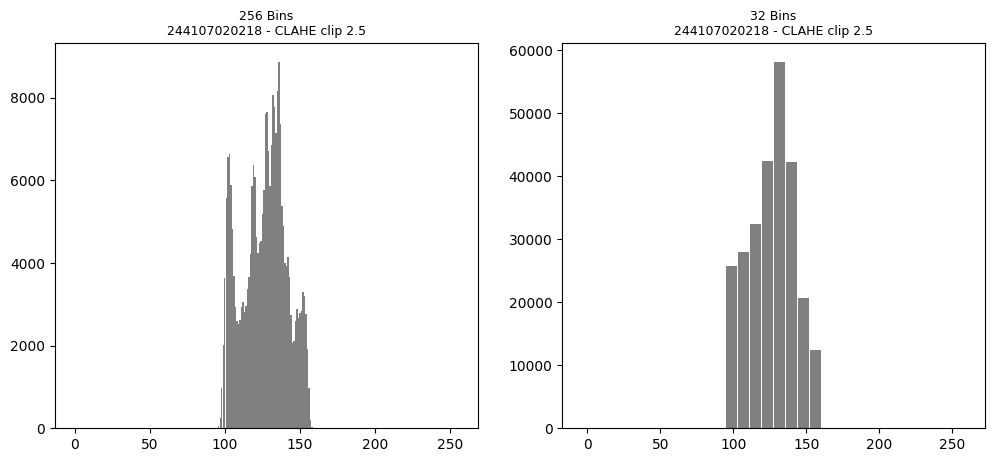

In [10]:
img_1b = cv.imread(f'{CONTOH}/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if img_1b is not None:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    hist_256, _ = np.histogram(img_1b.ravel(), bins=256, range=[0, 256])
    plt.bar(np.arange(256), hist_256, color='gray')
    plt.title(f"256 Bins\n{NIM} - CLAHE clip {PARAM['clip']}", fontsize=9)

    plt.subplot(1, 2, 2)
    hist_param, _ = np.histogram(img_1b.ravel(), bins=PARAM['bins'], range=[0, 256])
    plt.bar(np.linspace(0, 255, PARAM['bins']), hist_param, width=256/PARAM['bins'], color='gray')
    plt.title(f"{PARAM['bins']} Bins\n{NIM} - CLAHE clip {PARAM['clip']}", fontsize=9)
    plt.show()

Ketika jumlah bins diringkas (dari 256 menjadi 32), informasi yang hilang adalah detail kehalusan gradasi atau selisih kontras minor antar tingkat warna. Derajat keabuan yang tadinya berbeda tipis akan dikelompokkan ke dalam satu bin yang sama secara paksa, sehingga visualisasi sebaran statistik gambar tidak lagi detail.

**PRAKTIKUM E-2**

In [18]:
# Fungsi Ekualisasi Manual sesuai Flowchart
def manual_equalize_channel(channel):
    # Menghitung jumlah kemunculan (Frekuensi)
    hist, _ = np.histogram(channel.ravel(), bins=256, range=[0, 256])
    # Penjumlahan kumulatif (CDF)
    cdf = hist.cumsum()
    # Normalisasi dibagi dengan jumlah pixel
    cdf_normalized = cdf / cdf.max()
    # Implementasi skala warna (0-255)
    sk = np.round(cdf_normalized * 255).astype(np.uint8)
    # Transformasi kembali
    return sk[channel]

In [19]:
def plot_rgb_hist_before_after(image_path, judul_citra):
    img = cv.imread(image_path)
    if img is None:
        print(f"Gambar tidak ditemukan: {image_path}")
        return

    # Konversi BGR OpenCV ke RGB
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Pisahkan Kanal R, G, B
    r, g, b = cv.split(img_rgb)

    # Lakukan HE Manual untuk tiap kanal
    r_eq = manual_equalize_channel(r)
    g_eq = manual_equalize_channel(g)
    b_eq = manual_equalize_channel(b)

    # Hitung Histogram Asli
    hist_r, _ = np.histogram(r.ravel(), bins=256, range=[0, 256])
    hist_g, _ = np.histogram(g.ravel(), bins=256, range=[0, 256])
    hist_b, _ = np.histogram(b.ravel(), bins=256, range=[0, 256])

    # Hitung Histogram Sesudah Ekualisasi
    hist_r_eq, _ = np.histogram(r_eq.ravel(), bins=256, range=[0, 256])
    hist_g_eq, _ = np.histogram(g_eq.ravel(), bins=256, range=[0, 256])
    hist_b_eq, _ = np.histogram(b_eq.ravel(), bins=256, range=[0, 256])

    # Plotting Histogram (Sesuai image_400aec.png)
    names = np.arange(256)
    fig, axs = plt.subplots(2, 3, figsize=(15, 5), sharex=True, sharey=True)
    fig.suptitle(f'Histogram RGB plot - {judul_citra} | {NIM}')

    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

    # Baris Atas: Asli
    axs[0, 0].bar(names, hist_r, color='red')
    axs[0, 1].bar(names, hist_g, color='green')
    axs[0, 2].bar(names, hist_b, color='blue')

    # Baris Bawah: Setelah HE (Diberi sedikit transparansi / alpha meniru contoh acuan)
    axs[1, 0].bar(names, hist_r_eq, color='red', alpha=0.6)
    axs[1, 1].bar(names, hist_g_eq, color='green', alpha=0.6)
    axs[1, 2].bar(names, hist_b_eq, color='blue', alpha=0.6)

    plt.show()

    # Menampilkan Citra Sebelum vs Sesudah Ekualisasi RGB Manual
    img_eq_rgb = cv.merge([r_eq, g_eq, b_eq])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title(f'Asli {judul_citra}'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(img_eq_rgb); plt.title(f'Manual HE RGB {judul_citra}'); plt.axis('off')
    plt.show()

--- TAHAP 1: Citra lena_lc.jpg ---


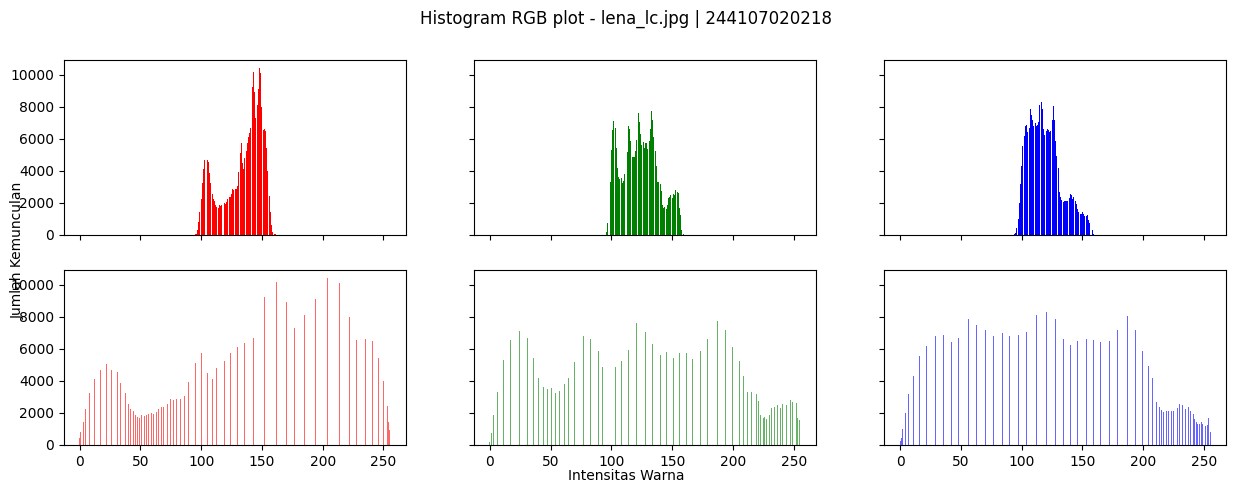

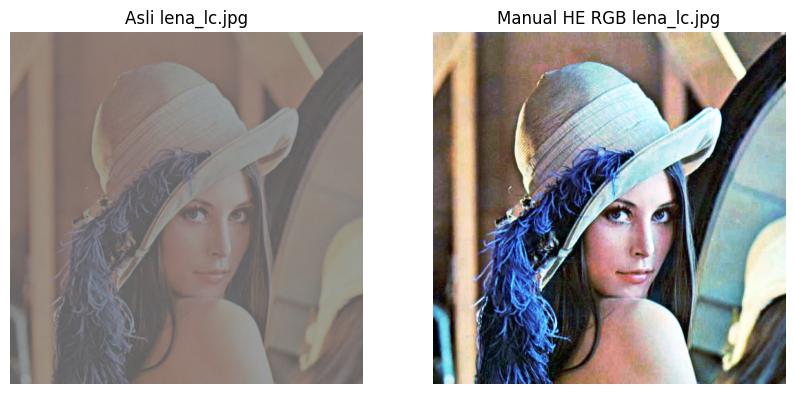

In [20]:
# ==============================================================
# EKSEKUSI TAHAP 1
# ==============================================================
print("--- TAHAP 1: Citra lena_lc.jpg ---")
plot_rgb_hist_before_after(f'{CONTOH}/lena_lc.jpg', 'lena_lc.jpg')


--- TAHAP 2: Citra KTP1a.jpg ---


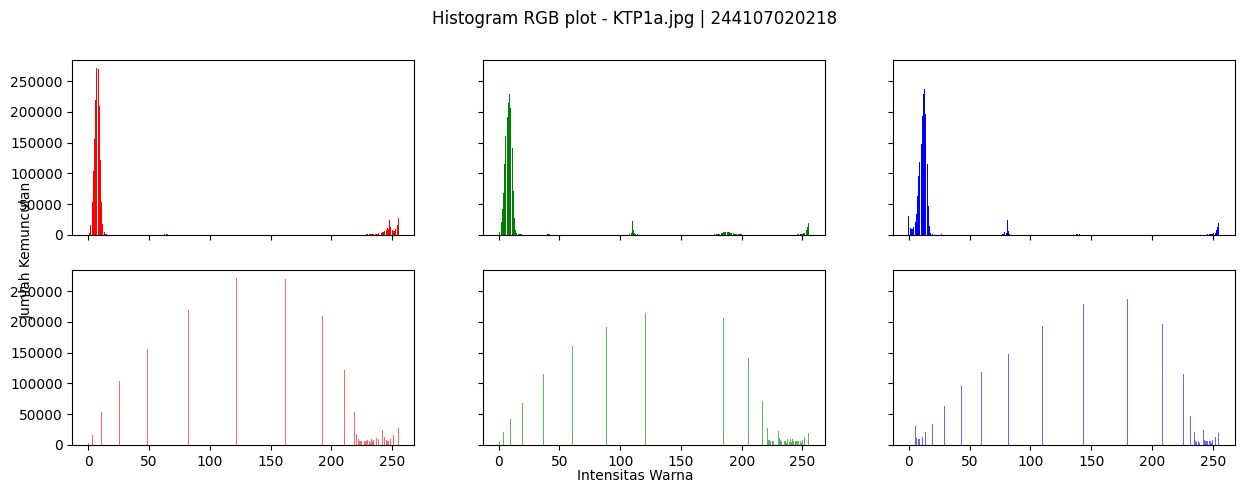

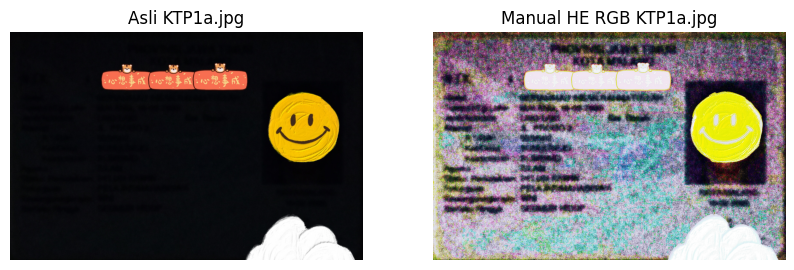

In [22]:
# ==============================================================
# EKSEKUSI TAHAP 2
# ==============================================================
print("\n--- TAHAP 2: Citra KTP1a.jpg ---")
plot_rgb_hist_before_after(f'{BASE}/KTP1a.jpg', 'KTP1a.jpg')


Uji pada /content/drive/MyDrive/PCVK/lena_lc.jpg -> Selisih maks HE Manual vs CV2: 0


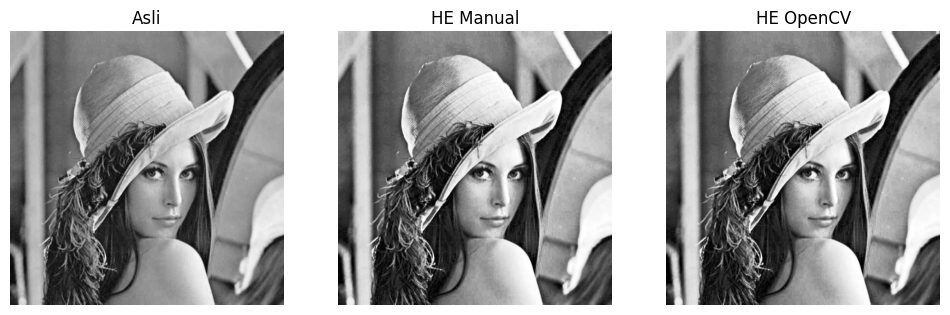


Uji pada /content/drive/MyDrive/PCVK/Image/244107020218/KTP1a.jpg -> Selisih maks HE Manual vs CV2: 0


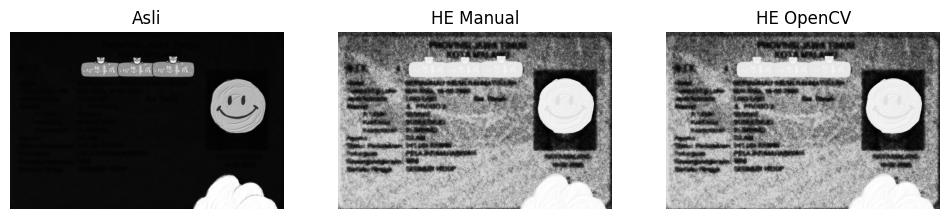

In [12]:
def manual_equalize(img):
    h = histogram_manual(img)
    p = h / img.size
    cdf = np.cumsum(p)
    sk = np.round(255 * cdf).astype(np.uint8) # S = (L-1) * CDF
    return sk[img]

for path in [f'{CONTOH}/lena_lc.jpg', f'{BASE}/KTP1a.jpg']:
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is not None:
        he_manual = manual_equalize(img)
        he_cv = cv.equalizeHist(img)

        diff = np.max(np.abs(he_manual.astype(int) - he_cv.astype(int)))
        print(f"\nUji pada {path} -> Selisih maks HE Manual vs CV2: {diff}")

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Asli'); plt.axis('off')
        plt.subplot(1, 3, 2); plt.imshow(he_manual, cmap='gray'); plt.title('HE Manual'); plt.axis('off')
        plt.subplot(1, 3, 3); plt.imshow(he_cv, cmap='gray'); plt.title('HE OpenCV'); plt.axis('off')
        plt.show()

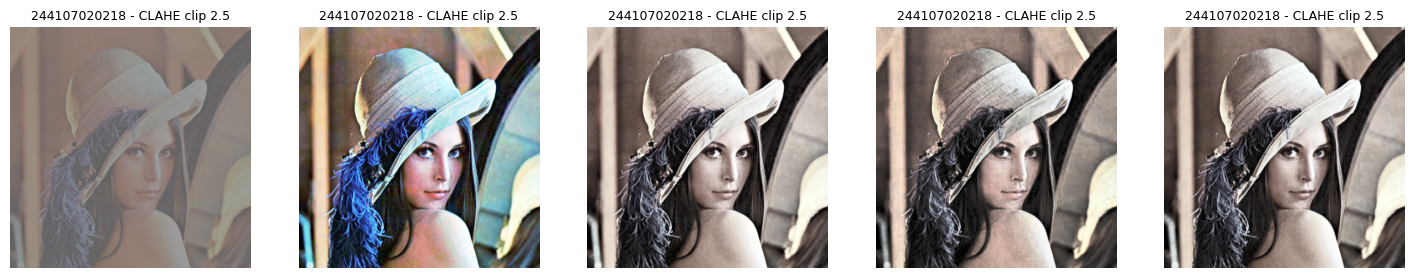

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            126.3
Ekualisasi B, G, R                55.04            130.1
Kanal Y                            0.12            130.1
Kanal V                            3.78            121.7
Kanal L                            3.94            125.9


In [13]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

bgr = cv.imread(f'{CONTOH}/lena_lc.jpg')
if bgr is not None:
    # 1. Ekualisasi per kanal (B, G, R)
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # 2. Kanal Y (YCrCb)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 3. Kanal V (HSV)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 4. Kanal L (LAB)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        set_title_wajib()
        plt.axis('off')
    plt.show()

    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

**PERTANYAAN**

**NO 1**

In [14]:
img_1a = cv.imread(f'{CONTOH}/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if img_1a is not None:
    he_1a = cv.equalizeHist(img_1a)

    # Hitung PSNR
    mse = np.mean((img_1a.astype(float) - he_1a.astype(float)) ** 2)
    psnr = 10 * np.log10((255 ** 2) / mse)
    print("Nilai PSNR setelah HE Global:", psnr)

Nilai PSNR setelah HE Global: 12.723209918705944


**NO 2**

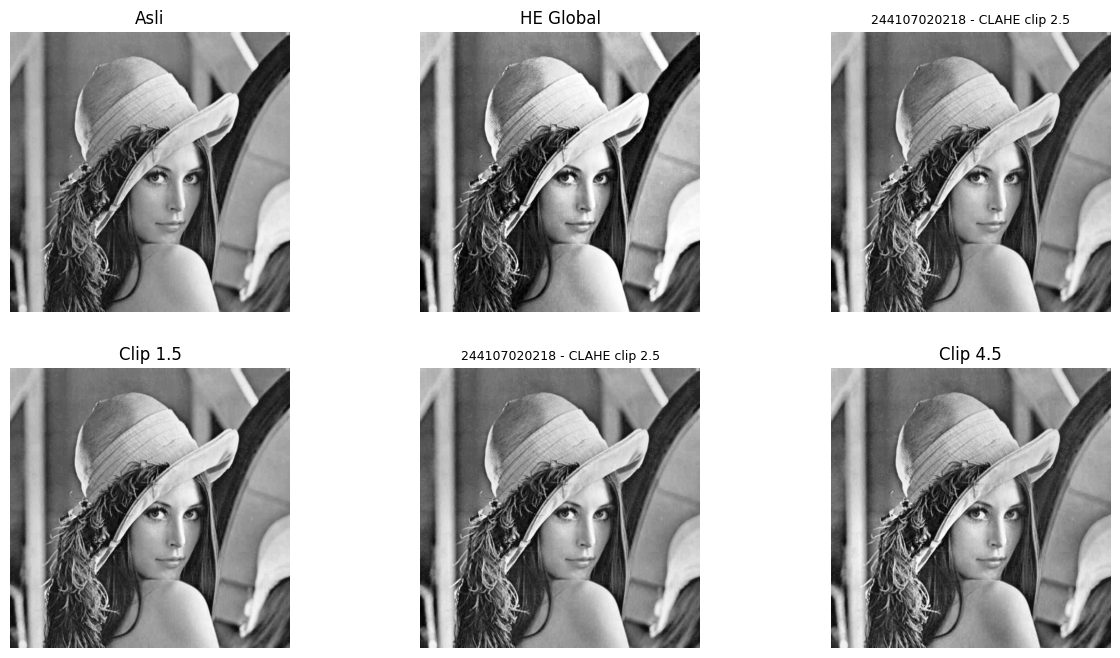

In [15]:
    # Uji CLAHE
    clahe_obj = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    clahe_1a = clahe_obj.apply(img_1a)

    # Variasi Clip CLAHE
    c_rendah = cv.createCLAHE(clipLimit=PARAM['clip'] - 1.0, tileGridSize=(PARAM['tile'], PARAM['tile']))
    c_tinggi = cv.createCLAHE(clipLimit=PARAM['clip'] + 2.0, tileGridSize=(PARAM['tile'], PARAM['tile']))

    plt.figure(figsize=(15, 8))
    plt.subplot(2, 3, 1); plt.imshow(img_1a, cmap='gray'); plt.title('Asli'); plt.axis('off')
    plt.subplot(2, 3, 2); plt.imshow(he_1a, cmap='gray'); plt.title('HE Global'); plt.axis('off')
    plt.subplot(2, 3, 3); plt.imshow(clahe_1a, cmap='gray'); set_title_wajib(); plt.axis('off')

    plt.subplot(2, 3, 4); plt.imshow(c_rendah.apply(img_1a), cmap='gray'); plt.title(f"Clip {PARAM['clip'] - 1.0}"); plt.axis('off')
    plt.subplot(2, 3, 5); plt.imshow(clahe_1a, cmap='gray'); set_title_wajib(); plt.axis('off')
    plt.subplot(2, 3, 6); plt.imshow(c_tinggi.apply(img_1a), cmap='gray'); plt.title(f"Clip {PARAM['clip'] + 2.0}"); plt.axis('off')
    plt.show()

**PRAKTIKUM E-3**

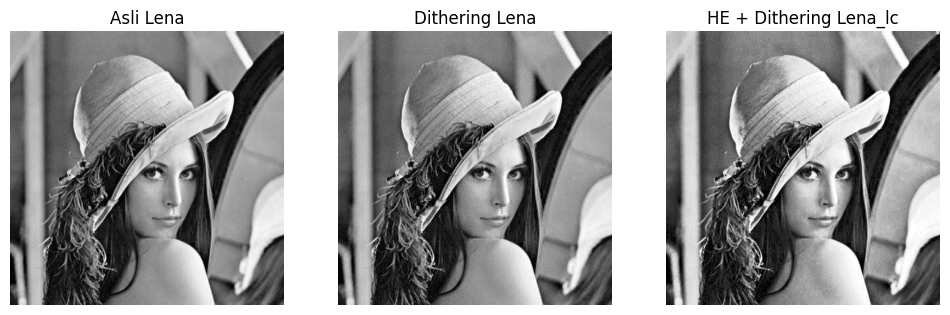

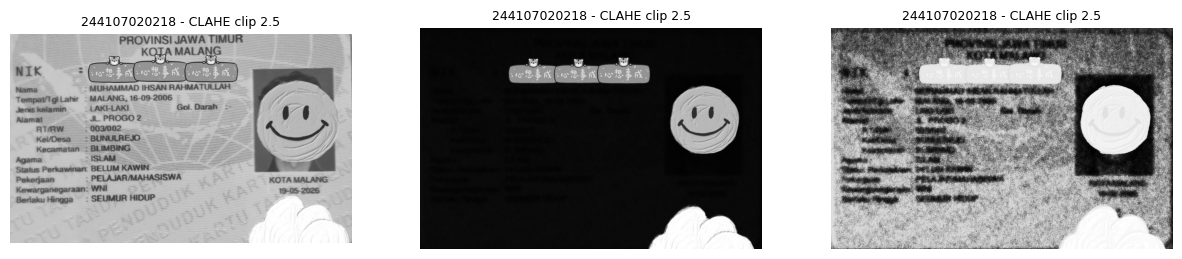

In [16]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7/16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3/16)
            if y + 1 < H:
                img[y + 1, x] += error * (5/16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1/16)

    return np.clip(img, 0, 255).astype(np.uint8)

# Tahap 1: Pembuktian Dithering Lena & Lena_lc.jpg
img_lena = cv.imread(f'{CONTOH}/lena.jpg', cv.IMREAD_GRAYSCALE)
img_lena_lc = cv.imread(f'{CONTOH}/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if img_lena is not None and img_lena_lc is not None:
    dith_lena = floyd_steinberg(img_lena, L=PARAM['L'])
    dith_he_lena = floyd_steinberg(cv.equalizeHist(img_lena_lc), L=PARAM['L'])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img_lena, cmap='gray'); plt.title('Asli Lena'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(dith_lena, cmap='gray'); plt.title('Dithering Lena'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(dith_he_lena, cmap='gray'); plt.title('HE + Dithering Lena_lc'); plt.axis('off')
    plt.show()

# Tahap 2: Dithering KTM1b.jpg & HE + Dithering KTM1a.jpg
img_1b = cv.imread(f'{BASE}/KTP1b.jpg', cv.IMREAD_GRAYSCALE)
img_1a = cv.imread(f'{BASE}/KTP1a.jpg', cv.IMREAD_GRAYSCALE)
if img_1b is not None and img_1a is not None:
    dith_1b = floyd_steinberg(img_1b, L=PARAM['L'])

    dith_asli_1a = floyd_steinberg(img_1a, L=PARAM['L'])
    dith_he_1a = floyd_steinberg(cv.equalizeHist(img_1a), L=PARAM['L'])

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(dith_1b, cmap='gray'); set_title_wajib(); plt.xlabel('Dithering lena'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(dith_asli_1a, cmap='gray'); set_title_wajib(); plt.xlabel('Dithering lena (Tanpa HE)'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(dith_he_1a, cmap='gray'); set_title_wajib(); plt.xlabel('HE -> Dithering lena'); plt.axis('off')
    plt.show()

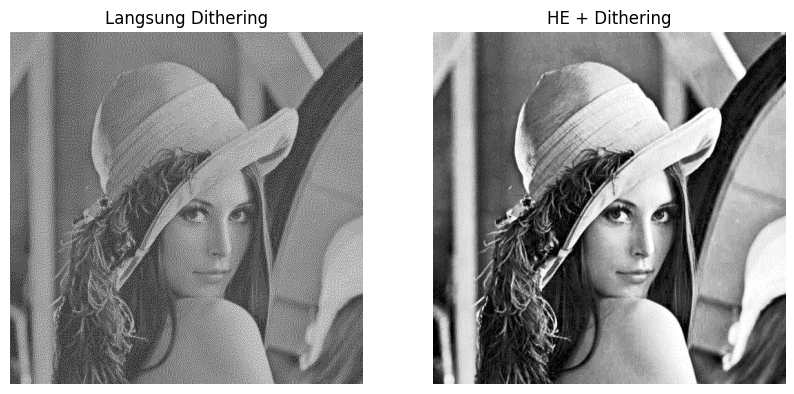

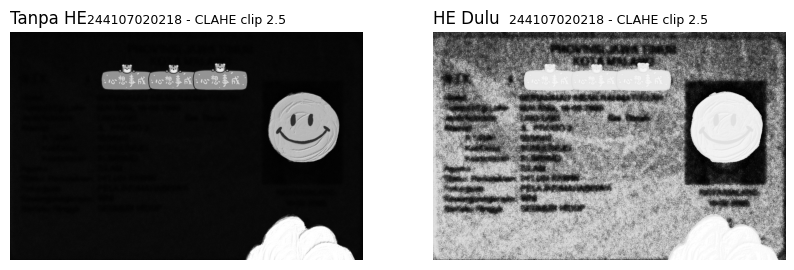

In [17]:
# Tahap 1: lena_lc.jpg
img_lena_lc = cv.imread(f'{CONTOH}/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if img_lena_lc is not None:
    dith_asli_lena = floyd_steinberg(img_lena_lc, L=PARAM['L'])
    dith_he_lena = floyd_steinberg(cv.equalizeHist(img_lena_lc), L=PARAM['L'])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(dith_asli_lena, cmap='gray'); plt.title('Langsung Dithering'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(dith_he_lena, cmap='gray'); plt.title('HE + Dithering'); plt.axis('off')
    plt.show()

# Tahap 2: KTM1a.jpg
img_1a = cv.imread(f'{BASE}/KTP1a.jpg', cv.IMREAD_GRAYSCALE)
if img_1a is not None:
    dith_asli_1a = floyd_steinberg(img_1a, L=PARAM['L'])
    dith_he_1a = floyd_steinberg(cv.equalizeHist(img_1a), L=PARAM['L'])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(dith_asli_1a, cmap='gray'); set_title_wajib(); plt.title('Tanpa HE', loc='left'); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(dith_he_1a, cmap='gray'); set_title_wajib(); plt.title('HE Dulu', loc='left'); plt.axis('off')
    plt.show()